In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import subprocess
import json

def run_bench(n: int, runs: int = 100) -> dict:
    cmd = ["cargo", "run", "--profile", "fast", "--bin", "bench", "--", str(n), str(runs)]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd="../../wasm")
    result.check_returncode()
    return json.loads(result.stdout)


In [4]:
ns_to_plot = list(range(6, 19))
all_data = {n: run_bench(n, runs=200) for n in ns_to_plot}

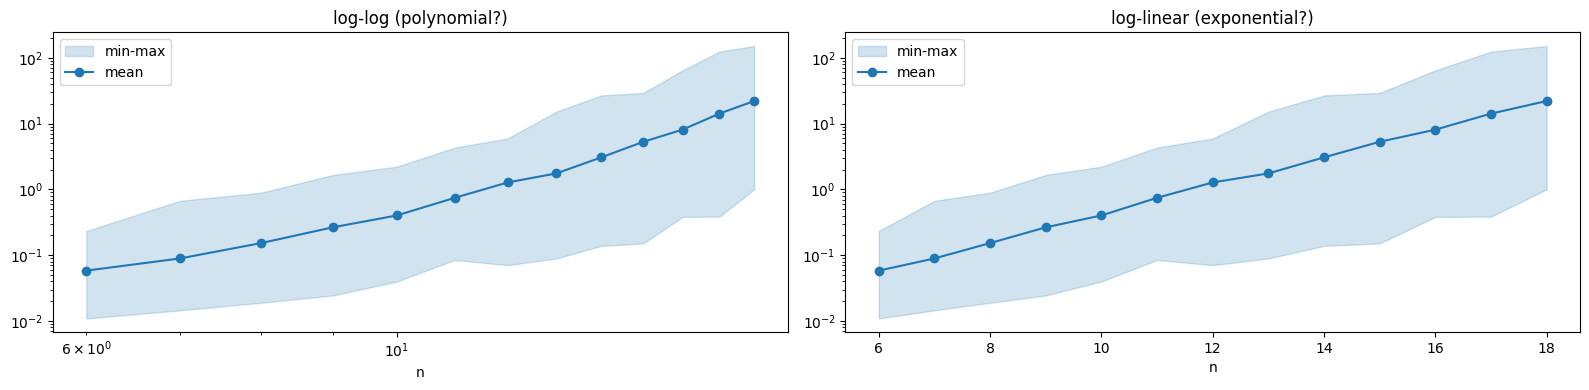

R² log-log  (polynomial):   0.9788  →  O(n^5.49)
R² log-lin  (exponential):  0.9992  →  ~1.646x per +1 n
verdict: exponential


In [6]:
from scipy import stats

ns = np.array(ns_to_plot, dtype=float)
means = np.array([np.mean(all_data[n]["ms"]) for n in ns_to_plot])
lows  = np.array([np.min(all_data[n]["ms"])  for n in ns_to_plot])
highs = np.array([np.max(all_data[n]["ms"])  for n in ns_to_plot])

# plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# log-log (straight = polynomial)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.fill_between(ns, lows, highs, alpha=0.2, color="tab:blue", label="min-max")
ax1.plot(ns, means, marker="o", color="tab:blue", label="mean")
ax1.set_xlabel("n"); ax1.set_title("log-log (polynomial?)"); ax1.legend()

# log-linear (straight = exponential)
ax2.set_yscale("log")
ax2.fill_between(ns, lows, highs, alpha=0.2, color="tab:blue", label="min-max")
ax2.plot(ns, means, marker="o", color="tab:blue", label="mean")
ax2.set_xlabel("n"); ax2.set_title("log-linear (exponential?)"); ax2.legend()

plt.tight_layout()
plt.show()

# big-O
log_ns, log_means = np.log(ns), np.log(means)

r2_poly = stats.pearsonr(log_ns, log_means).statistic ** 2
r2_exp  = stats.pearsonr(ns, log_means).statistic ** 2

poly_slope, _ = np.polyfit(log_ns, log_means, 1)
exp_slope,  _ = np.polyfit(ns, log_means, 1)

verdict = "exponential" if r2_exp > r2_poly else "polynomial"
print(f"R² log-log  (polynomial):   {r2_poly:.4f}  →  O(n^{poly_slope:.2f})")
print(f"R² log-lin  (exponential):  {r2_exp:.4f}  →  ~{np.exp(exp_slope):.3f}x per +1 n")
print(f"verdict: {verdict}")

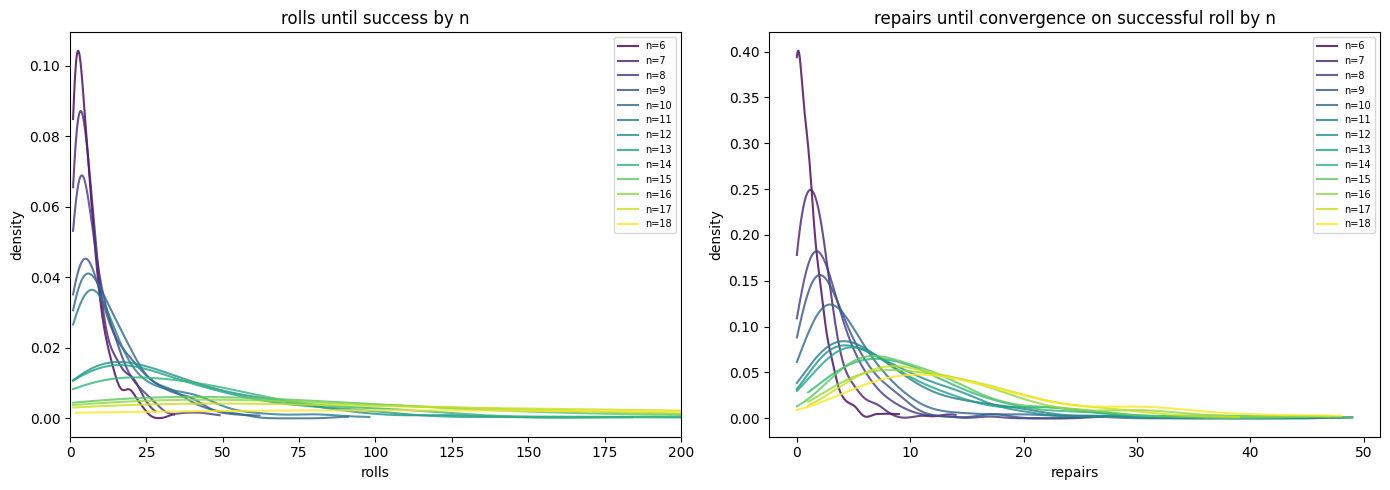

In [11]:
from scipy.stats import gaussian_kde

palette = plt.cm.viridis(np.linspace(0, 1, len(ns_to_plot)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for color, n in zip(palette, ns_to_plot):
    for ax, key in [(ax1, "rolls"), (ax2, "success_repairs")]:
        vals = np.array(all_data[n][key], dtype=float)
        if vals.std() == 0:
            continue
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, kde(xs), color=color, alpha=0.8, label=f"n={n}")

ax1.set_xlabel("rolls"); ax1.set_ylabel("density")
ax1.set_xlim(left=0, right=200)
ax1.set_title("rolls until success by n")
ax1.legend(fontsize=7)

ax2.set_xlabel("repairs"); ax2.set_ylabel("density")
ax2.set_title("repairs until convergence on successful roll by n")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

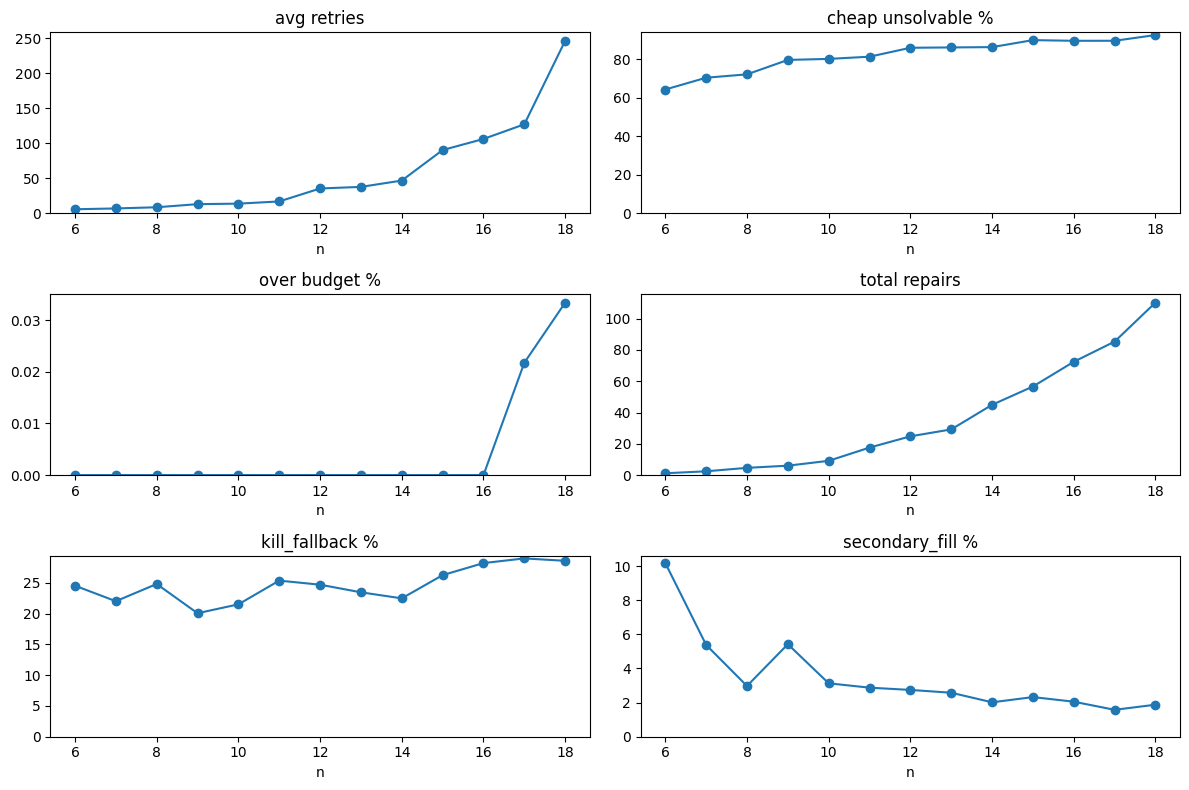

In [17]:
def avg(n, key):
    return np.mean(all_data[n][key])


def pct(n, key, denom_key):
    return 100.0 * np.sum(all_data[n][key]) / np.sum(all_data[n][denom_key])


keys_fns = [
    ("avg retries", lambda n: avg(n, "rolls")),
    ("cheap unsolvable %", lambda n: pct(n, "unsolvable", "rolls")),
    ("over budget %", lambda n: pct(n, "over_budget", "solves")),
    ("total repairs", lambda n: avg(n, "repairs")),
    ("kill_fallback %", lambda n: pct(n, "kill_fallback", "repairs")),
    ("secondary_fill %", lambda n: pct(n, "secondary_fills", "rolls"))
]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, (title, fn) in zip(axes.flat, keys_fns):
    ax.plot(ns_to_plot, [fn(n) for n in ns_to_plot], marker="o")
    ax.set_xlabel("n")
    ax.set_title(title)
    ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

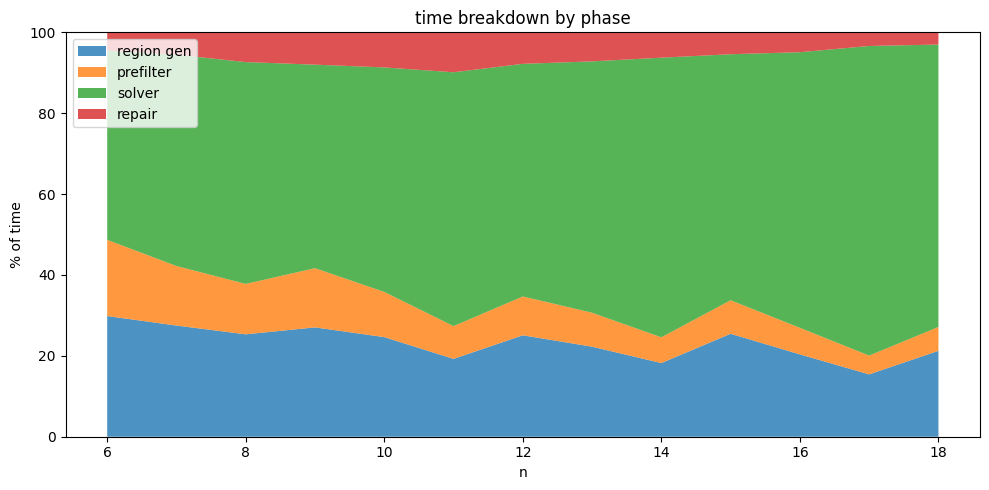

In [18]:
phases = ["t_regions", "t_solvable", "t_solve", "t_kill"]
labels = ["region gen", "prefilter", "solver", "repair"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# compute each phase as % of total t_* time per n
pcts = []
for phase in phases:
    vals = []
    for n in ns_to_plot:
        total = sum(np.mean(all_data[n][p]) for p in phases)
        vals.append(100.0 * np.mean(all_data[n][phase]) / total)
    pcts.append(vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(ns_to_plot, pcts, labels=labels, colors=colors, alpha=0.8)
ax.set_xlabel("n")
ax.set_ylabel("% of time")
ax.set_title("time breakdown by phase")
ax.set_ylim(0, 100)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
